In [1]:
## neden bu data
##Yaklaşık 1300 satır ve Çok temiz.
##8 columns  7 özellik + 1 hedef değişken.
##Hem sayısal hem kategorik veri içeriyor.
##Regresyon için çok uygun.

In [2]:
## https://www.kaggle.com/datasets/mirichoi0218/insurance

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("../data/insurance.csv")

In [5]:
##Veri Analizi (EDA)

In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.shape

(1338, 7)

In [8]:
type(df.shape)

tuple

In [9]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [10]:
type(df.columns)

pandas.core.indexes.base.Index

In [11]:
df.info

<bound method DataFrame.info of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [13]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [14]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [15]:
##3 categoric columns (sex, smoker, region) and  4 numeric columns (age, bmi, children, charges)

In [16]:
df.isnull()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [17]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [18]:
df["sex"].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [19]:
df["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [20]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [21]:
##outlier varmı yoksa normal mi dağılıyor hedef değişken kontrol  
import matplotlib.pyplot as plt
%matplotlib inline

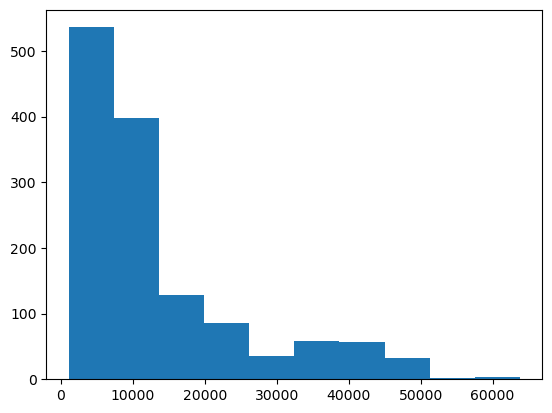

In [22]:
plt.hist(df["charges"])
plt.savefig("../images/age_distribution.png",dpi=300,bbox_inches="tight")
plt.show()


In [23]:
##ilk özellik(feature ) ile hedef(target) arasındaki ilişki  grafiği

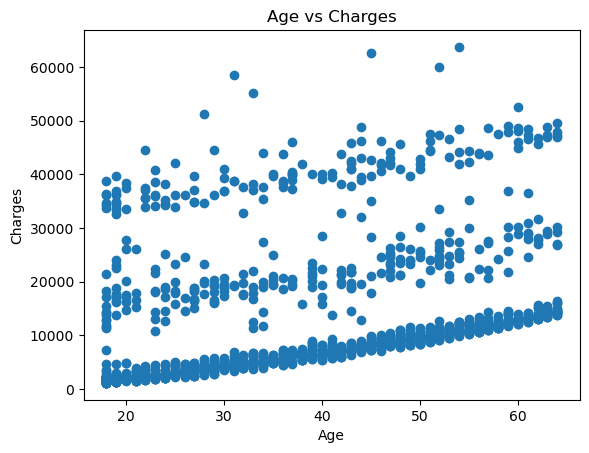

In [24]:
plt.scatter(df["age"], df["charges"])
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges")
plt.savefig("../images/Age_vs_Charges.png",dpi=300,bbox_inches="tight")
plt.show()

In [25]:
## import new Libraries

In [26]:
import seaborn as sns

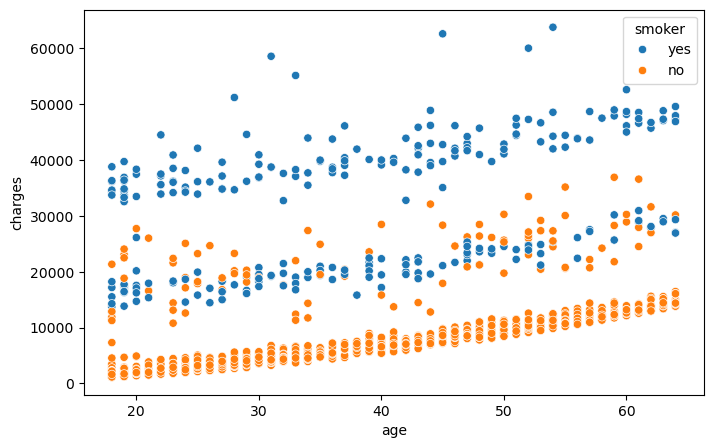

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x="age",y="charges",hue="smoker")

plt.savefig("../images/Age_Charges_with_smoker.png",dpi=300,bbox_inches="tight")

plt.show()

In [28]:
##Sigorta primleri yaşla birlikte artıyor
### Insurance charges generally increase with age.

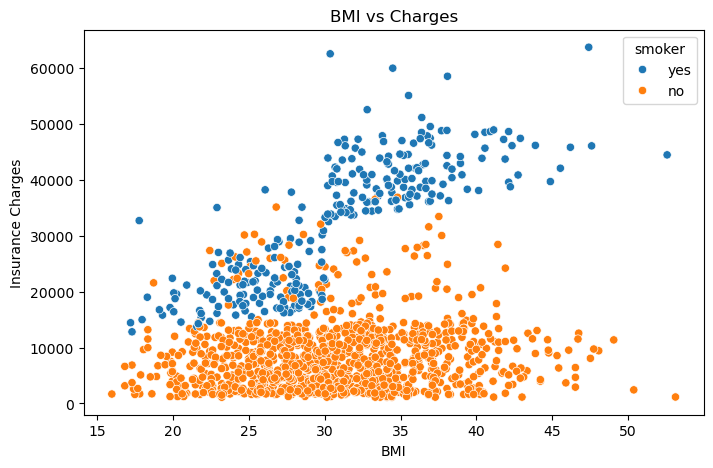

In [29]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x="bmi",y="charges",hue="smoker")

plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.show()

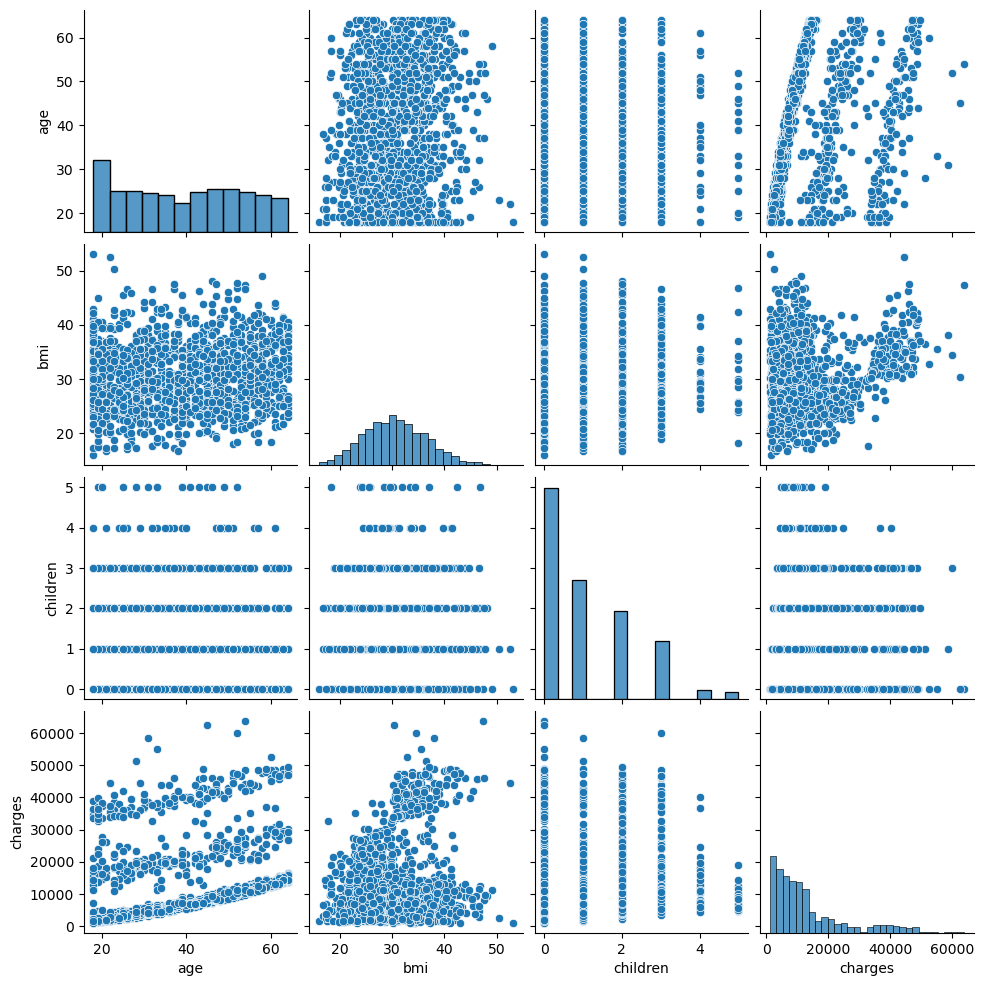

In [30]:
sns.pairplot(df)
plt.show()

In [31]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [32]:
X = df.drop("charges",axis=1)
y=df["charges"]

In [36]:
type(X)

pandas.core.frame.DataFrame

In [37]:
type(y)

pandas.core.series.Series

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [47]:
from sklearn.compose import ColumnTransformer

In [49]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [50]:
numeric_features = ["age", "bmi", "children"]

categorical_features = ["sex", "smoker", "region"]

In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(), categorical_features)
    ]
)

In [52]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [53]:
from sklearn.linear_model import LinearRegression

In [54]:
lrmodel=LinearRegression()

In [55]:
lrmodel.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
y_pred = lrmodel.predict(X_test)